### 📍STEP 1 — Data Understanding & Cleaning

In [1]:
#REQUIRED LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Step 1A — Load Dataset
student_dt = pd.read_csv("StudentsPerformance.csv")
student_dt.head()
# The dataset contains student demographic and performance information including gender, lunch type,parental education,and subject scores.

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
#Rows & columns count
student_dt.shape

(1000, 8)

In [4]:
#Column Information
student_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
#Step 1B — Statistical Summary
student_dt.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
#Step 1C — Data Cleaning
student_dt.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
student_dt.duplicated().sum()

np.int64(0)

#### Data Report 
### Step 1 - Summary:

- The dataset contains 1000 rows and 8 columns
- Dataset successfully loaded and inspected
- No major missing value issues detected
- Duplicate records handled
- Data types verified for analysis
- Dataset prepared for Exploratory Data Analysis (EDA)

### 📊 STEP 2 — Exploratory Data Analysis (EDA)

In [8]:
# 2.1 Mean, Median, Standard Deviation:
# Mean
student_dt[['math score','reading score','writing score']].mean()

math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

In [9]:
# Median
student_dt[["math score","reading score","writing score"]].median()

math score       66.0
reading score    70.0
writing score    69.0
dtype: float64

In [10]:
# Standard Deviation
student_dt[["math score","reading score","writing score"]].std()

math score       15.163080
reading score    14.600192
writing score    15.195657
dtype: float64

### Insight
- Reading Score as Higher average Perfarmance : 69.169
- Writing Score as Higher variability
- Math score are relatively lower compared to reading and writing 

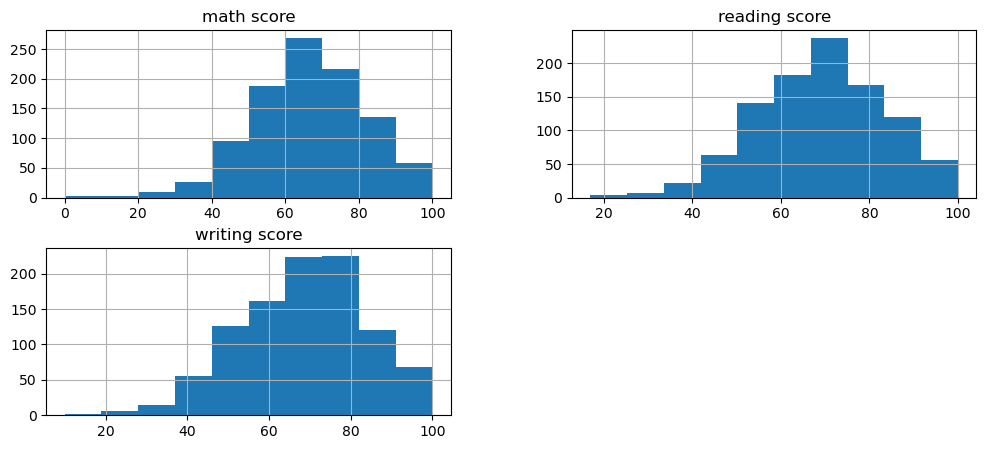

In [16]:
# 2.2. Distribution Analysis
student_dt[['math score','reading score','writing score']].hist(figsize = (12,5))
plt.show()

#### Distribution Insights
- Math scores appear approximately normally distributed.
- Reading and writing scores show slight negative skewness.
- Most students score between 50 and 80.

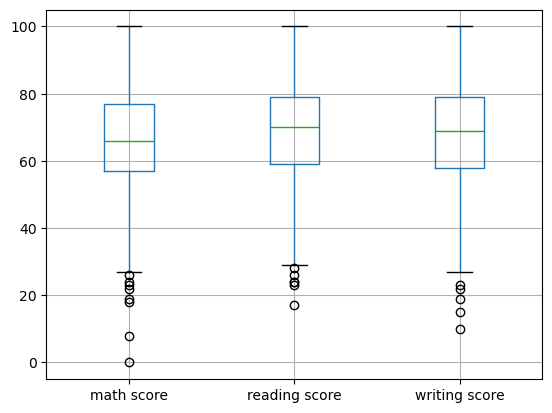

In [20]:
# 2.3 Boxplot Analysis(Outliers)
student_dt[['math score','reading score','writing score']].boxplot()
plt.show()

#### Outlier Insights
- All subjects contain low-end outliers.
- Writing scores contain slightly fewer extreme outliers.
- Several students perform exceptionally low compared to the majority.

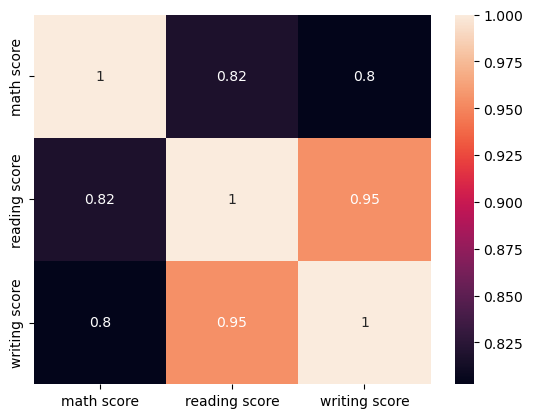

In [24]:
import seaborn as sns 
sns.heatmap(student_dt[['math score','reading score','writing score']].corr(),annot= True)
plt.show()

#### Correlation Insights
- Reading and writing scores have very strong positive correlation(0.95).
- Math scores also show positive correlation with reading and writing.
- Students performing well in reading tend to perform well in writing.

In [29]:
# 2.5 Lunch Type Analysis
student_dt.groupby('lunch')[['math score','reading score','writing score']].mean()

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


#### Lunch Analysis Insights
- Students with standard lunch perform significantly better.
- Free/reduced lunch students show comparatively lower scores.
- Socio-economic factors may influence academic performance.

In [36]:
# 2.6 Probability Analysis
len(student_dt[student_dt["math score"] > 70]) / len(student_dt)

0.391

In [47]:
standard_lunch = student_dt[student_dt['lunch'] == 'standard']

len(standard_lunch[standard_lunch["math score"] > 70]) / len(standard_lunch)

0.4790697674418605

#### Probability Insights
- Students with standard lunch have higher probability of scoring above 70 in math.
- Conditional probability highlights performance differences between groups.

In [57]:
# 2.7 Z-Score Outlier Detection 
student_dt['math_z'] = (
    student_dt['math score'] - student_dt['math score'].mean()
) / student_dt['math score'].std()

In [61]:
(student_dt['math_z'].abs() > 2) .sum()

np.int64(46)

#### Z-Score Insights
- Approximately 4–5% of students are statistical outliers.
- Extreme scores exist on both high and low ends.
- Writing scores contain slightly fewer outliers compared to math and reading.

### 📝 Final EDA Summary 
#### Step 2 Summary

- Reading scores show the highest overall performance.
- Reading and writing exhibit strong positive correlation.
- Multiple low-score outliers are present across subjects.
- Students with standard lunch perform significantly better.
- Statistical analysis reveals moderate variability in student performance.